# Jaguar Re-ID — MLP (Optimized)

**Goal**: push an MLP (Flatten → hidden layers → Dense) as far as possible.  
**Key levers**: data augmentation, BatchNormalization, Dropout, architecture depth, LR scheduling.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks, regularizers
from sklearn.preprocessing import normalize

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: []


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR      = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR   = os.path.join(DATA_DIR, 'cleaned')
TRAIN_IMG_DIR = os.path.join(CLEANED_DIR, 'train')
TEST_IMG_DIR  = os.path.join(CLEANED_DIR, 'test')
OUTPUT_DIR    = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR = r'C:\tf\logs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

IMG_SIZE    = 224
NUM_CLASSES = 31
BATCH_SIZE  = 32
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Data loading

In [3]:
train_df      = pd.read_csv(os.path.join(CLEANED_DIR, 'train_split.csv'))
val_df        = pd.read_csv(os.path.join(CLEANED_DIR, 'val_split.csv'))
test_pairs_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test pairs: {len(test_pairs_df)}")

def load_images_from_df(df, img_dir):
    images, labels = [], []
    for _, row in df.iterrows():
        img = Image.open(os.path.join(img_dir, row['filename'])).convert('RGB')
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

print("Loading train images...")
X_train, y_train = load_images_from_df(train_df, TRAIN_IMG_DIR)
print("Loading val images...")
X_val, y_val     = load_images_from_df(val_df, TRAIN_IMG_DIR)

print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")

def load_test_images(img_dir):
    test_images = {}
    for fname in sorted(os.listdir(img_dir)):
        if fname.endswith('.png'):
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            test_images[fname] = np.array(img, dtype=np.float32) / 255.0
    return test_images

print("Loading test images...")
test_images = load_test_images(TEST_IMG_DIR)
print(f"Test images: {len(test_images)}")

Train: 1516 | Val: 379 | Test pairs: 137270
Loading train images...
Loading val images...
X_train: (1516, 224, 224, 3) | X_val: (379, 224, 224, 3)
Loading test images...
Test images: 371


## 2. Data augmentation pipeline

MLPs benefit much more from augmentation than linear models because they can learn non-linear combinations.  
We add **rotation** and **zoom** on top of flip/brightness/contrast.

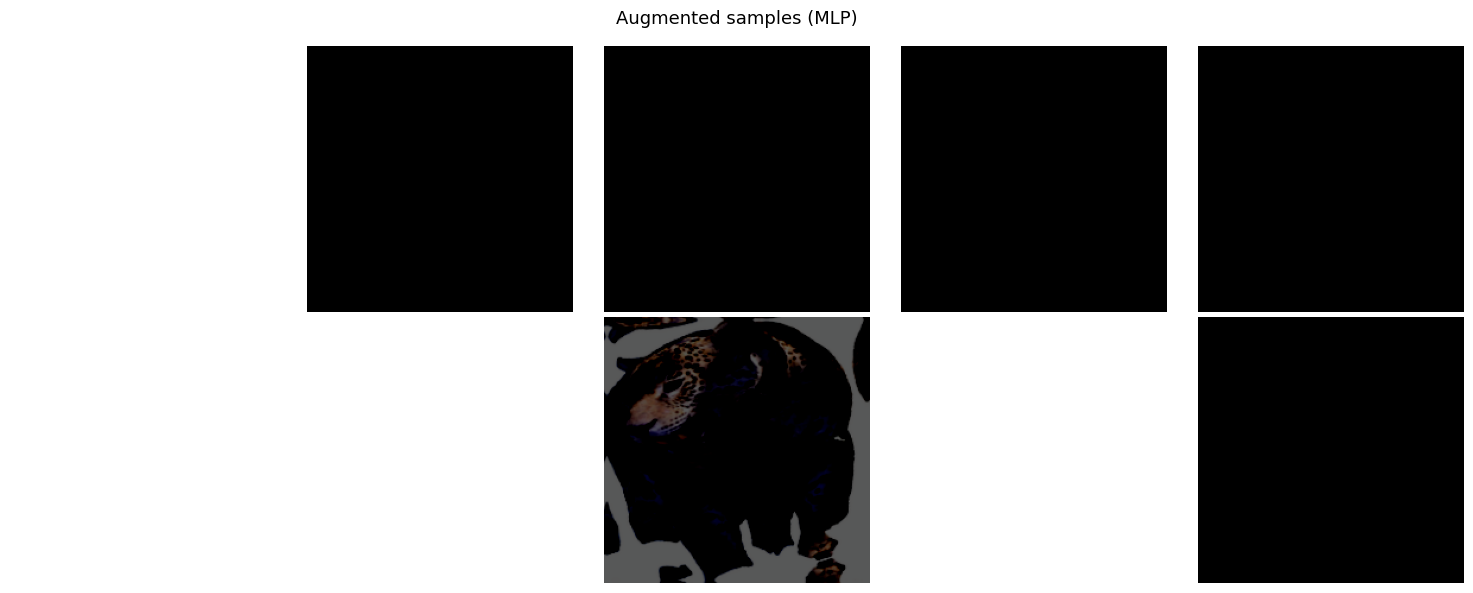

In [4]:
augmentation_layers = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),         # ±29° — varies pose angle
    layers.RandomZoom((-0.1, 0.1)),      # slight crop/zoom
    layers.RandomBrightness(0.25),
    layers.RandomContrast(0.25),
], name='augmentation')

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
        ds = ds.batch(BATCH_SIZE)
        ds = ds.map(
            lambda x, y: (augmentation_layers(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )
    else:
        ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)

# Visualize augmented samples
sample_batch, _ = next(iter(train_ds))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Augmented samples (MLP)', fontsize=13)
for i in range(10):
    axes[i // 5][i % 5].imshow(np.clip(sample_batch[i].numpy(), 0, 1))
    axes[i // 5][i % 5].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_augmented_samples.png'), dpi=120, bbox_inches='tight')
plt.show()

## 3. Model architecture

```
Input → Flatten → [Dense → BatchNorm → Activation → Dropout]×N → Dense(31, softmax)
```

**BatchNormalization** stabilizes training on the very high-dimensional flattened input (150k dims).  
**Dropout** is the primary regularizer — we sweep its rate in the HP study.

In [ ]:
def build_mlp(hidden_units, dropout_rate=0.4, activation='relu', l2_strength=1e-4):
    """
    hidden_units : list of ints, e.g. [1024, 512, 256]
    dropout_rate : applied after each hidden Dense
    AveragePooling2D(4,4) réduit 224×224 → 56×56 → 9408 dims (vs 150528 sans pooling)
    → évite l'allocation de 588 MiB pour Dense(150528 → 1024)
    """
    units_str = '-'.join(str(u) for u in hidden_units)
    model = keras.Sequential(name=f'mlp_h{units_str}_dr{dropout_rate}')
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
    model.add(layers.AveragePooling2D(pool_size=(4, 4)))   # 224→56, 9408 dims
    model.add(layers.Flatten())

    for units in hidden_units:
        model.add(layers.Dense(
            units,
            kernel_regularizer=regularizers.l2(l2_strength)
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    return model

# Preview default architecture
build_mlp([512, 256]).summary()

## 4. Hyperparameter study

We sweep three axes independently:  
1. **Architecture** (depth + width)  
2. **Dropout rate**  
3. **Learning rate**

In [6]:
def train_and_eval(model, lr=1e-3, run_name='run'):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, 'mlp_hp', run_name)
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_accuracy', patience=15,
                restore_best_weights=True, mode='max'
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir)
        ],
        verbose=0
    )
    _, val_acc = model.evaluate(val_ds, verbose=0)
    best_epoch = np.argmax(hist.history['val_accuracy']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return val_acc, hist

In [7]:
# --- Architecture sweep (fixed dropout=0.4, lr=1e-3) ---
arch_candidates = {
    'shallow [512,256]'      : [512, 256],
    'medium [1024,512,256]'  : [1024, 512, 256],
    'deep [2048,1024,512,256]': [2048, 1024, 512, 256],
}
arch_results = {}

print("=== Architecture sweep (dropout=0.4, lr=1e-3) ===")
for name, units in arch_candidates.items():
    m = build_mlp(units, dropout_rate=0.4)
    safe_name = name.replace(' ', '_').replace('[', '').replace(']', '').replace(',', '-')
    val_acc, hist = train_and_eval(m, lr=1e-3, run_name=f'arch_{safe_name}')
    arch_results[name] = {'val_acc': val_acc, 'hist': hist.history}

=== Architecture sweep (dropout=0.4, lr=1e-3) ===
  arch_shallow_512-256: val_acc=0.1055 (best epoch=8)
  arch_medium_1024-512-256: val_acc=0.0950 (best epoch=3)
  arch_deep_2048-1024-512-256: val_acc=0.0950 (best epoch=2)


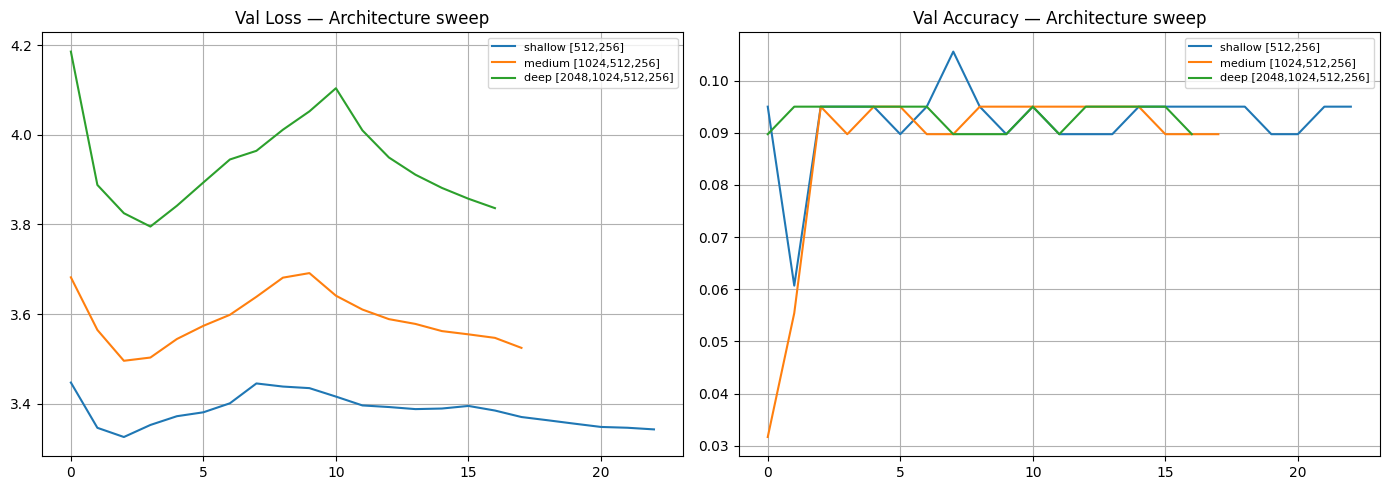

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in arch_results.items():
    axes[0].plot(res['hist']['val_loss'],     label=name)
    axes[1].plot(res['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — Architecture sweep'); axes[0].legend(fontsize=8); axes[0].grid(True)
axes[1].set_title('Val Accuracy — Architecture sweep'); axes[1].legend(fontsize=8); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_arch_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# --- Dropout rate sweep (fixed arch=[1024,512,256], lr=1e-3) ---
dropout_candidates = [0.2, 0.4, 0.5, 0.6]
dropout_results = {}

print("=== Dropout sweep (arch=[1024,512,256], lr=1e-3) ===")
for dr in dropout_candidates:
    m = build_mlp([1024, 512, 256], dropout_rate=dr)
    val_acc, hist = train_and_eval(m, lr=1e-3, run_name=f'dropout_{dr}')
    dropout_results[dr] = {'val_acc': val_acc, 'hist': hist.history}

=== Dropout sweep (arch=[1024,512,256], lr=1e-3) ===
  dropout_0.2: val_acc=0.0950 (best epoch=2)
  dropout_0.4: val_acc=0.0950 (best epoch=1)
  dropout_0.5: val_acc=0.0950 (best epoch=3)
  dropout_0.6: val_acc=0.0950 (best epoch=1)


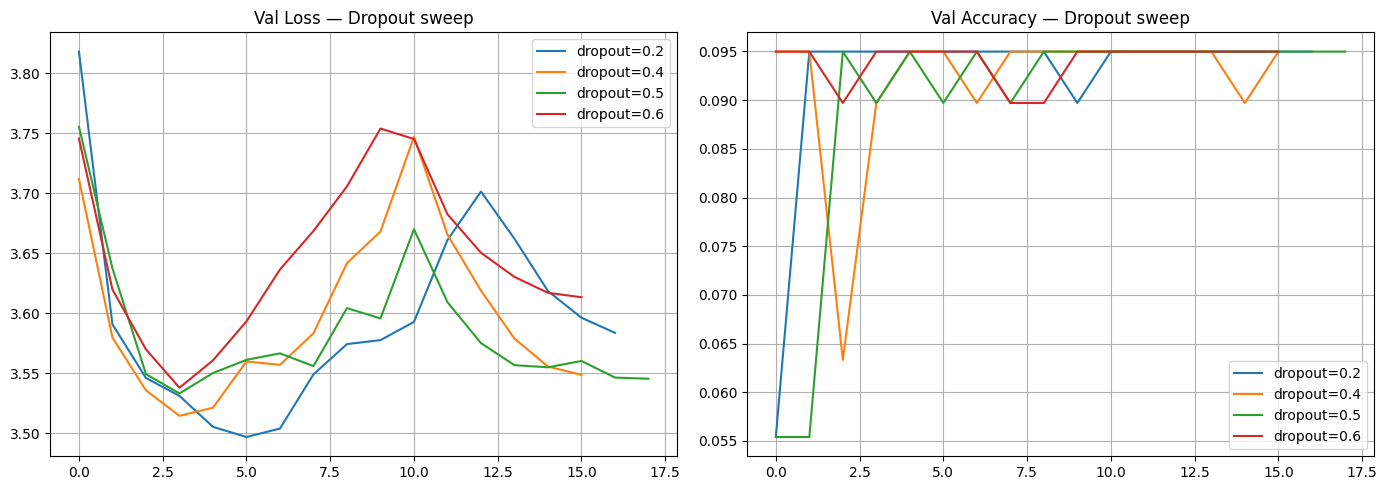

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for dr, res in dropout_results.items():
    axes[0].plot(res['hist']['val_loss'],     label=f'dropout={dr}')
    axes[1].plot(res['hist']['val_accuracy'], label=f'dropout={dr}')
axes[0].set_title('Val Loss — Dropout sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — Dropout sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_dropout_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# --- Learning rate sweep (fixed arch=[1024,512,256], dropout=0.4) ---
lr_candidates = [1e-2, 1e-3, 3e-4, 1e-4]
lr_results = {}

print("=== LR sweep (arch=[1024,512,256], dropout=0.4) ===")
for lr in lr_candidates:
    m = build_mlp([1024, 512, 256], dropout_rate=0.4)
    val_acc, hist = train_and_eval(m, lr=lr, run_name=f'lr_{lr}')
    lr_results[lr] = {'val_acc': val_acc, 'hist': hist.history}

=== LR sweep (arch=[1024,512,256], dropout=0.4) ===
  lr_0.01: val_acc=0.0950 (best epoch=2)


MemoryError: Unable to allocate 588. MiB for an array with shape (150528, 1024) and data type float32

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr, res in lr_results.items():
    axes[0].plot(res['hist']['val_loss'],     label=f'lr={lr}')
    axes[1].plot(res['hist']['val_accuracy'], label=f'lr={lr}')
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_lr_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Results summary

In [ ]:
rows = []
for name, res in arch_results.items():
    rows.append({'Config': f'arch={name}, dr=0.4, lr=1e-3', 'Val Accuracy': res['val_acc']})
for dr, res in dropout_results.items():
    rows.append({'Config': f'arch=[1024,512,256], dr={dr}, lr=1e-3', 'Val Accuracy': res['val_acc']})
for lr, res in lr_results.items():
    rows.append({'Config': f'arch=[1024,512,256], dr=0.4, lr={lr}', 'Val Accuracy': res['val_acc']})

results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
print("=== HP Study Results ===")
display(results_df)

best_row = results_df.iloc[0]
print(f"\nBest: {best_row['Config']} → val_acc={best_row['Val Accuracy']:.4f}")

## 6. Final training on full dataset

Retrain on all available data with the best hyperparameters found above.

In [ ]:
# --- Best config: edit these if needed after reading results_df ---
BEST_UNITS   = [1024, 512, 256]
BEST_DROPOUT = 0.4
BEST_LR      = 1e-3

all_train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_clean.csv'))
print("Loading all training images...")
X_all, y_all = load_images_from_df(all_train_df, TRAIN_IMG_DIR)
print(f"Full train: {X_all.shape}")

full_ds = make_dataset(X_all, y_all, training=True)

final_mlp = build_mlp(BEST_UNITS, dropout_rate=BEST_DROPOUT)
final_mlp.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log_dir = os.path.join(LOG_DIR, 'mlp_final', datetime.now().strftime('%Y%m%d-%H%M%S'))
final_hist = final_mlp.fit(
    full_ds,
    epochs=100,
    callbacks=[
        callbacks.ReduceLROnPlateau(
            monitor='loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
        ),
        callbacks.TensorBoard(log_dir=final_log_dir)
    ],
    verbose=1
)
print(f"Final train acc: {final_hist.history['accuracy'][-1]:.4f}")

## 7. Kaggle submission

Extract the **penultimate layer** (last hidden layer before softmax) as embedding.  
This gives a richer, non-linear embedding than the raw flattened pixels.

In [ ]:
# Embedding = output of the last Dropout layer (before softmax Dense)
embedding_model = keras.Model(
    inputs=final_mlp.input,
    outputs=final_mlp.layers[-2].output,
    name='mlp_embedding'
)
print(f"Embedding layer: {final_mlp.layers[-2].name} — dim={final_mlp.layers[-2].output.shape[-1]}")

test_filenames = sorted(test_images.keys())
test_array = np.array([test_images[f] for f in test_filenames])

test_embeddings      = embedding_model.predict(test_array, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)

print(f"Embeddings shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.sum(
    test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx],
    axis=1
)
similarities = np.clip(similarities, 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, 'submission_mlp_optimized.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head(10))

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
print("Submission format OK")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(similarities, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(similarities.mean(), color='red', linestyle='--',
                label=f'Mean: {similarities.mean():.3f}')
axes[0].set_xlabel('Similarity score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Similarity distribution — MLP (optimized)')
axes[0].legend()

train_accs = final_hist.history['accuracy']
axes[1].plot(train_accs, color='steelblue', label='Train')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Final model — training curve')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_final_results.png'), dpi=120, bbox_inches='tight')
plt.show()

## 8. Summary

In [ ]:
print("=" * 60)
print("MLP (OPTIMIZED) — SUMMARY")
print("=" * 60)
print(f"""
Architecture  : Flatten → [Dense→BN→ReLU→Dropout]×{len(BEST_UNITS)} → Dense(31)
Hidden units  : {BEST_UNITS}
Dropout rate  : {BEST_DROPOUT}
L2 strength   : 1e-4
Optimizer     : Adam (lr={BEST_LR}, ReduceLROnPlateau)
Augmentation  : Flip + Rotation + Zoom + Brightness + Contrast
Training      : full dataset ({len(all_train_df)} images), 100 epochs

HP Study top-3:
{results_df.head(3).to_string(index=False)}

Submission    : submissions/submission_mlp_optimized.csv
TensorBoard   : tensorboard --logdir={LOG_DIR}
""")